In [ ]:
# ============================================================
# BLOQUE 1: Fundamentos básicos de Electrónica de Potencia.
# Tema 3: Introducción a los dispositivos para electrónica de potencia
#
# Grado de Electrónica - Electrónica de Potencia
# Septiembre/2026 (c)
#
# Objetivos:
# 1. reconocer el comportamiento unidireccional de un diodo;
# 2. distinguir entre un modelo ideal, un modelo con caída constante y un modelo exponencial;
# 3. interpretar una curva corriente–tensión \(I\!-\!V\);
# 4. comprender el papel de la tensión \(V_{GS}\) en un NMOS;
# 5. interpretar de forma introductoria las regiones de corte y conducción;
# 6. utilizar Python y ngspice para visualizar características estáticas de dispositivos.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import os

# Configuración de gráficos
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

![Modelos de diodo](figures/diodo_modelos.png)



# 1. El diodo

El diodo es un dispositivo semiconductor de dos terminales que permite el paso de corriente principalmente en una dirección. Sus terminales se denominan **ánodo** y **cátodo**. Se define la tensión en el diodo como $v_D=v_A-v_K$ y la corriente como $i_D$ que es positiva desde el ánodo hacia el cátodo. Así, si si $v_D$ es suficientemente positivo, el diodo conduce y si $v_D$ es negativo, la corriente es muy pequeña y el diodo se considera en corte.

* Modelo ideal. si el diodo está apagado (*OFF*), la corriente $i_D=0$. Por otra parte, si el diodo está encendido (*ON*), $v_D=0.$

* Modelo de caída constante o de primera aproximación. Una aproximación práctica sencilla consiste en considerar que el diodo comienza a conducir cuando $v_D \gtrsim V_\gamma .$ Para un diodo de silicio puede utilizarse inicialmente $V_\gamma \approx 0.7\ \text{V}.$

* Modelo exponencial o de segunda aproximación. Una representación más física viene dada por la ecuación de Shockley,$i_D=I_S\left(e^{\frac{v_D}{nV_T}}-1\right)$, donde: $I_S$ es la corriente de saturación; $n$ es el factor de idealidad; y $V_T$ es la tensión térmica.

A temperatura ambiente $V_T\approx25.85\ \text{mV}.$ Este modelo se utilizará solamente para visualizar la forma de la característica $I-V$.

In [ ]:

# Parámetros del modelo de Shockley
Is          = 1e-12        # A
n           = 1.8
VT          = 25.85e-3     # V

In [ ]:
# Tensión aplicada al diodo
vD          = np.linspace(-0.5, 0.9, 1500)

# Corriente del diodo
iD          = Is * (np.exp(vD/(n*VT)) - 1)

# Se limita únicamente la representación para que
# la zona exponencial no domine completamente la gráfica.
iD_plot     = np.clip(iD, -1e-3, 0.1)

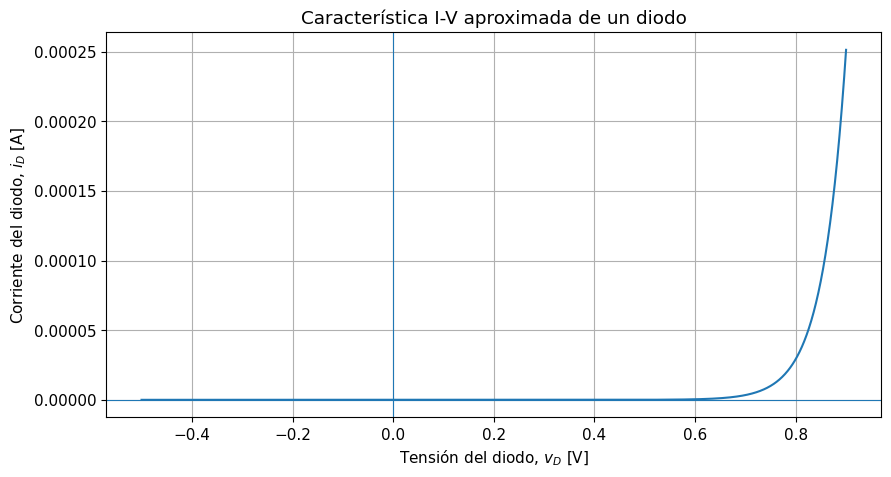

In [ ]:
plt.plot(vD, iD_plot)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Tensión del diodo, $v_D$ [V]")
plt.ylabel("Corriente del diodo, $i_D$ [A]")
plt.title("Característica I-V aproximada de un diodo")
plt.grid(True)
plt.show()

La característica presenta dos comportamientos principales.

* Polarización inversa. Para $v_D<0$ la corriente permanece muy próxima a cero dentro del modelo utilizado.

* Polarización directa. Cuando $v_D$ aumenta en sentido positivo, la corriente crece rápidamente.

Por ello, en análisis elementales suele reemplazarse la característica exponencial por modelos más sencillos. La elección del modelo depende del nivel de precisión requerido.

# 2. Introducción al MOSFET de canal N

![Figura 2. Característica Estática del MOSFET](figures/mosfet.png)

Un MOSFET de canal N tiene cuatro terminales, tres son consideradas principales: (1) **Gate** o compuerta \(G\); (2)**Drain** o drenador \(D\); (3)
**Source** o surtidor \(S\). En una primera aproximación, su conducción entre drenador ($D$) y surtidor (S) está controlada por $V_{GS}=V_G-V_S.$ Existe una tensión característica denominada **tensión umbral** $V_{TH}$. De forma simplificada:

* MOSFET en corte. $V_{GS}<V_{TH}$

* MOSFET en condución. $V_{GS}>V_{TH}$

> En este tema no se estudia todavía un MOSFET de potencia ni sus pérdidas de conmutación. El objetivo es únicamente comprender la idea básica de control mediante $V_{GS}$.

Como modelo pedagógico, en una región idealizada de saturación puede escribirse:

$$
\boxed{
I_D=
\frac{k_n}{2}
(V_{GS}-V_{TH})^2
}
\qquad
V_{GS}>V_{TH}.
$$

Si $V_{GS}\le V_{TH},$ se aproxima: $I_D=0.$ Este modelo cuadrático sirve para introducir el concepto, aunque no pretende representar con precisión un transistor moderno.

# MOSFET con ngspice: del punto de operación al funcionamiento como interruptor

En los siguientes ejemplos se utilizará un modelo sencillo de transistor NMOS para estudiar progresivamente su funcionamiento. El objetivo no es representar con gran precisión un MOSFET comercial o un transistor perteneciente a una tecnología de fabricación concreta, sino relacionar las ecuaciones básicas del MOSFET con los resultados obtenidos mediante simulación.

En todos los primeros ejemplos se utilizará el modelo:

```text
.model NMOS NMOS LEVEL=1 KP=200u VTO=0.7 LAMBDA=0.02
```

El modelo `LEVEL=1` permite trabajar con una representación relativamente sencilla del MOSFET. Los parámetros principales que se utilizarán son:

* $K_P$, relacionado con la capacidad de conducción del transistor.
* $V_{TO}$, correspondiente aproximadamente a la tensión umbral $V_T$.
* $\lambda$, que introduce la dependencia de la corriente de drenador con $V_{DS}$ en la región de saturación.

La geometría del transistor se define mediante: $W=10\,\mu\text{m}, L=1\,\mu\text{m},$ por lo que:$\frac{W}{L}=10.$


## Ejemplo 1. Punto de operación de un transistor NMOS

Se estudia un único MOSFET sometido a tensiones constantes,  $V_{GS}=0.8\text{ V}$ y $V_{DS}=1.8\text{ V}.$ El objetivo es determinar el **punto de operación** del transistor y relacionar los valores calculados por ngspice con las ecuaciones básicas del MOSFET.

* Se define la tensión de overdrive como $V_{OV}=V_{GS}-V_T$. Entonces,  $V_{GS}> V_T=V_{TO}=0.7\text{ V}$, para este ejemplo, $V_{OV}=0.8-0.7=0.1\text{ V}.$  También, es común redefinir esta tensión como tensión de saturación $V_{DSAT}\approx V_{OV}=0.1\text{ V}$.

* En el modelo básico del MOSFET, la frontera entre las regiones lineal y de saturación viene dada aproximadamente por $V_{DS} > V_{GS}-V_T$. Para este ejemplo, $V_{DS}=1.8\text{ V},$ de modo que la tensión $V_{DS}>V_{DSAT}.$

> El transistor se encuentra, por tanto, en la **región de saturación**.

* Para un MOSFET de canal largo, usando la nomenclatura ngspice, la corriente del drenador puede escribirse aproximadamente como $I_D=\frac{1}{2}K_P\frac{W}{L}(V_{GS}-V_T)^2(1+\lambda V_{DS})$. La combinación $\beta=K_P\frac{W}{L}$ vale $\beta=200\,\mu\frac{10}{1}
=2\,\text{mA/V}^2.$ Por tanto, $I_D\approx10.4\,\mu\text{A}.$

* Análisis ```.op```. La instrucción $\texttt{op}$ solicita a ngspice que calcule el punto de operación DC del circuito. Después se imprimen diferentes variables $I_D, g_m, g_{ds}$, y $V_{DSAT}.$ ```print v(gate) v(drain) @m1[id] @m1[gm] @m1[gds] @m1[vdsat]```


Este primer ejemplo permite comprobar que las ecuaciones básicas del MOSFET y el modelo utilizado por el simulador producen resultados coherentes.



## Ejemplo 2. Característica de transferencia $I_D(V_{GS})$

Se mantiene constante la tensión $V_{DS}=1.8\text{ V},$ mientras que la tensión de puerta se modifica, $0\leq V_{GS}\leq1.8\text{ V}$. Con ello se obteniene la **característica de transferencia**: $I_D=f(V_{GS})$.

* Ngspice realiza el barrido mediante: ```text dc VGS 0 1.8 0.01``` La tensión $V_{GS}$ aumenta desde $0$ hasta $1.8$ V utilizando incrementos de $0.01$ V. Para cada valor de $V_{GS}$, ngspice resuelve el circuito y calcula la correspondiente $I_D$.

* MOSFET apagado. Cuando $V_{GS}<V_T,$ el modelo básico considera al MOSFET en corte, $I_D\approx0.$ Es decir para $V_{GS}<0.7\text{ V},$  se espera una corriente prácticamente nula.



* MOSFET encendido. Cuando la tensión de puerta $V_{GS}>V_T,$ se forma el canal y comienza a circular corriente. Dado que la tensión $V_{DS} = V_{OV}=V_{GS}-V_T$, el MOSFET está en saturación y como consecuencia $I_D\propto(V_{GS}-V_T)^2.$ Por ello, la corriente aumenta rápidamente al aumentar $V_{GS}$.


* En SPICE, la corriente de una fuente de tensión se considera positiva cuando entra por el terminal positivo de la fuente. Debido a la orientación de la fuente `VDS`, la corriente calculada por SPICE tiene signo contrario a la convención utilizada normalmente para $I_D$, por tanto, $I_D=-I(VDS).$ De ahí que el comando utilizado sea ```plot -i(vds)```


> La gráfica puede dividirse conceptualmente en dos partes $V_{GS}<V_T
\quad\Rightarrow\quad I_D\approx0,$ y $V_{GS}>V_T \quad\Rightarrow\quad
I_D>0.$ Este experimento permite visualizar directamente el papel de la **tensión umbral** en el control de la conducción del MOSFET.


## Ejemplo 3. Características de salida $I_D(V_{DS})$

Se modifica $V_{DS}$ mientras se repite el análisis para distintos valores de $V_{GS}$, obteniendo una familia de curvas $I_D=f(V_{DS})$ para diferentes valores de $V_{GS}.$ El barrido utilizado es $0\leq V_{DS}\leq1.8\text{ V}$ y $
0.5\leq V_{GS}\leq1.2\text{ V}.$ En ngspice se realizan dos barridos anidados mediante  ```dc VDS 0 1.8 0.02 VGS 0.5 1.2 0.1``` El primer barrido corresponde a $V_{DS}$. El resultado es una familia de características de salida.

* Región de corte. Cuando $V_{GS}<V_T,$ el transistor permanece prácticamente apagado, $I_D\approx0.$ Por ejemplo, las curvas correspondientes a $V_{GS}=0.5\text{ V}$ y $V_{GS}=0.6\text{ V}$ deben presentar una corriente prácticamente nula para este modelo.

* Región lineal. Cuando $V_{GS}>V_T$ y $V_{DS}<V_{GS}-V_T,$ el transistor se encuentra en la denominada región lineal o triodo. La corriente puede aproximarse mediante $I_D=K_P\frac WL\left[(V_{GS}-V_T)V_{DS}-\frac{V_{DS}^{2}}{2}\right].$ En esta región, aumentar $V_{DS}$ provoca un aumento considerable de $I_D$.

* Región de saturación. Cuando $V_{DS}\geq V_{GS}-V_T,$ el transistor entra en saturación. Idealmente, la corriente sería prácticamente independiente de $V_{DS}$. Sin embargo, el modelo incluye $\lambda=0.02,$ por lo que aparece una pequeña pendiente en las curvas de saturación. Este efecto se representa aproximadamente mediante $I_D=I_{D0}(1+\lambda V_{DS}).$ Por esta razón, las curvas obtenidas en simulación no son perfectamente horizontales.


> Este experimento permite identificar gráficamente las tres situaciones fundamentales: $\text{corte}, \text{región lineal}, \text{saturación}.$ Además muestra que $V_{GS}$ controla el nivel de corriente disponible en el transistor.


## Ejemplo 4. Exportación de resultados para Python

Se utiliza exactamente el mismo circuito y el mismo doble barrido que el ejemplo anterior. La diferencia consiste en que ahora los resultados de ngspice se guardan en un archivo para poder procesarlos posteriormente utilizando Python. De esta manera se separan dos tareas, la primera se encarga de realizar la simulación con ngspice, y y la segunda, se encarga de analizar y dibujar los resultados en python.

* Exportación mediante `wrdata`. El comando ```wrdata ids_results.csv v(gate) v(drain) -i(vds)``` exporta los vectores seleccionados. Conceptualmente queremos guardar $V_{GS}, V_{DS}, I_D.$ De nuevo: $I_D=-I(VDS).$ La extensión `.csv` se utiliza por comodidad, pero `wrdata` genera fundamentalmente una tabla de datos ASCII y no necesariamente un archivo CSV convencional separado mediante comas.

* Nombre de los vectores. La instrucción ```set wr_vecnames``` hace que ngspice escriba los nombres de los vectores en la primera fila del archivo. Además,```set wr_singlescale``` evita repetir innecesariamente el vector utilizado como escala cuando los datos comparten la misma escala. Finalmente, ```option numdgt=8``` permite aumentar el número de cifras significativas utilizadas al escribir los resultados.

### Flujo de trabajo

El procedimiento completo puede representarse como:

$$
\boxed{\text{Netlist}}
\rightarrow
\boxed{\text{ngspice}}
\rightarrow
\boxed{\text{archivo de datos}}
\rightarrow
\boxed{\text{Python}}
\rightarrow
\boxed{\text{gráficas y análisis}}.
$$

Este método será especialmente útil posteriormente, cuando se quieran realizar cálculos adicionales, comparar modelos o construir gráficas personalizadas utilizando `numpy`, `pandas` y `matplotlib`.



In [ ]:
# Instalar ngspice para linux dentro del entorno COLAB
!apt-get update -qq
!apt-get install -y ngspice

In [ ]:

# Comprobar la instalación solicitando la versión ngspice instalada
!ngspice -v

In [ ]:
netlist_nmos_4 = r"""
*=========================================================
* Example 4. One NMOS transistor
* Sweep VDS
*=========================================================

.title Example 4. Sweep VDS

*---------------------------------------------------------
* Circuit parameters
*---------------------------------------------------------
.param W_VALUE          = 10u
.param L_VALUE          = 1u

*---------------------------------------------------------
* VDS sweep parameters
*---------------------------------------------------------
.param VDS_SWEEP_START  = 0
.param VDS_SWEEP_STOP   = 1.8
.param VDS_SWEEP_STEP   = 0.02

*---------------------------------------------------------
* VGS sweep parameters
*---------------------------------------------------------
.param VGS_SWEEP_START  = 0.5
.param VGS_SWEEP_STOP   = 1.2
.param VGS_SWEEP_STEP   = 0.1

*---------------------------------------------------------
* Models
*---------------------------------------------------------
.model NMOS NMOS LEVEL=1 KP=200u VTO=0.7 LAMBDA=0.02

*---------------------------------------------------------
* Circuit netlist
*---------------------------------------------------------
VGS gate  0 DC 0
VDS drain 0 DC 0

M1 drain gate 0 0 NMOS W={W_VALUE} L={L_VALUE}

*---------------------------------------------------------
* Analysis
*---------------------------------------------------------
.dc VDS {VDS_SWEEP_START} {VDS_SWEEP_STOP} {VDS_SWEEP_STEP} VGS {VGS_SWEEP_START} {VGS_SWEEP_STOP} {VGS_SWEEP_STEP}

*---------------------------------------------------------
* Export results
*---------------------------------------------------------
.control

    run

    set wr_vecnames
    set filetype=ascii

    wrdata 4_example_results.csv v(gate) v(drain) i(VDS)

.endc

.end
"""

In [ ]:
# Crear netlist
with open("nmos_4.sp", "w") as f:
    f.write(netlist_nmos_4)
print("Netlist creado: nmos_4.sp")

In [ ]:
# Ejecutar ngspice
result = subprocess.run(["ngspice", "-b", "nmos_4.sp"], capture_output=True, text=True)
print(result.stdout)

if result.stderr:
    print("Mensajes:")
    print(result.stderr)

print("Código de salida:", result.returncode)

if result.returncode == 0:
    print("Simulación completada correctamente.")

In [ ]:
# Leer resultados de ngspice
df = pd.read_csv("4_example_results.csv",    sep=r"\s+",  engine="python")

# Mostrar las primeras filas
df.head()

In [ ]:
print("Columnas disponibles:")
print(df.columns)

print("\nNúmero de muestras:")
print(len(df))

print("\nPrimeras filas:")
display(df.head())

In [ ]:

for vgs, datos in df.groupby("v(gate)"):
    plt.plot(datos["v(drain)"],  -datos["i(VDS)"],  label=f"$V_{{GS}}$ = {vgs:.1f} V")
plt.xlabel("$V_{DS}$ [V]")
plt.ylabel("$I_D$ [A]")
plt.title("Características de salida del NMOS")
plt.grid(True)
plt.legend(loc="upper right")
plt.show()
plt.tight_layout()

plt.show()

In [ ]:

VTH = 0.7
KP = 200e-6
W = 10e-6
L = 1e-6

K = 0.5 * KP * W / L

# VDS de la frontera
vds_boundary = np.linspace(0, 1.2 - VTH, 300)

# Corriente sobre la frontera
id_boundary = K * vds_boundary**2

# Curvas obtenidas de ngspice
for vgs, datos in df.groupby("v(gate)"):
    plt.plot( datos["v(drain)"],  -datos["i(VDS)"],  label=f"$V_{{GS}}$ = {vgs:.1f} V" )

# Frontera entre triodo y saturación
plt.plot(vds_boundary,  id_boundary,   "--", linewidth=2, label="Frontera triodo-saturación")

plt.xlabel("$V_{DS}$ [V]")
plt.ylabel("$I_D$ [A]")
plt.title("Características de salida del NMOS")

plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()

plt.show()